In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

# Quick check
print(df.shape)
print(df['Diabetes_binary'].value_counts())
print(df.isnull().sum().sum())  # should be 0

(253680, 22)
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64
0


In [4]:
df = df.drop_duplicates()  # 253,680 → 229,474 rows

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch

In [6]:
C0 = '#4C9BE8'   # non-diabetic blue
C1 = '#E8624C'   # diabetic red
GRAY = '#cccccc'
BG = '#0f0f0f'
GRID = '#2a2a2a'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': GRID, 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'text.color': 'white', 'grid.color': GRID,
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'font.family': 'monospace'
})

d0 = df[df['Diabetes_binary'] == 0]
d1 = df[df['Diabetes_binary'] == 1]

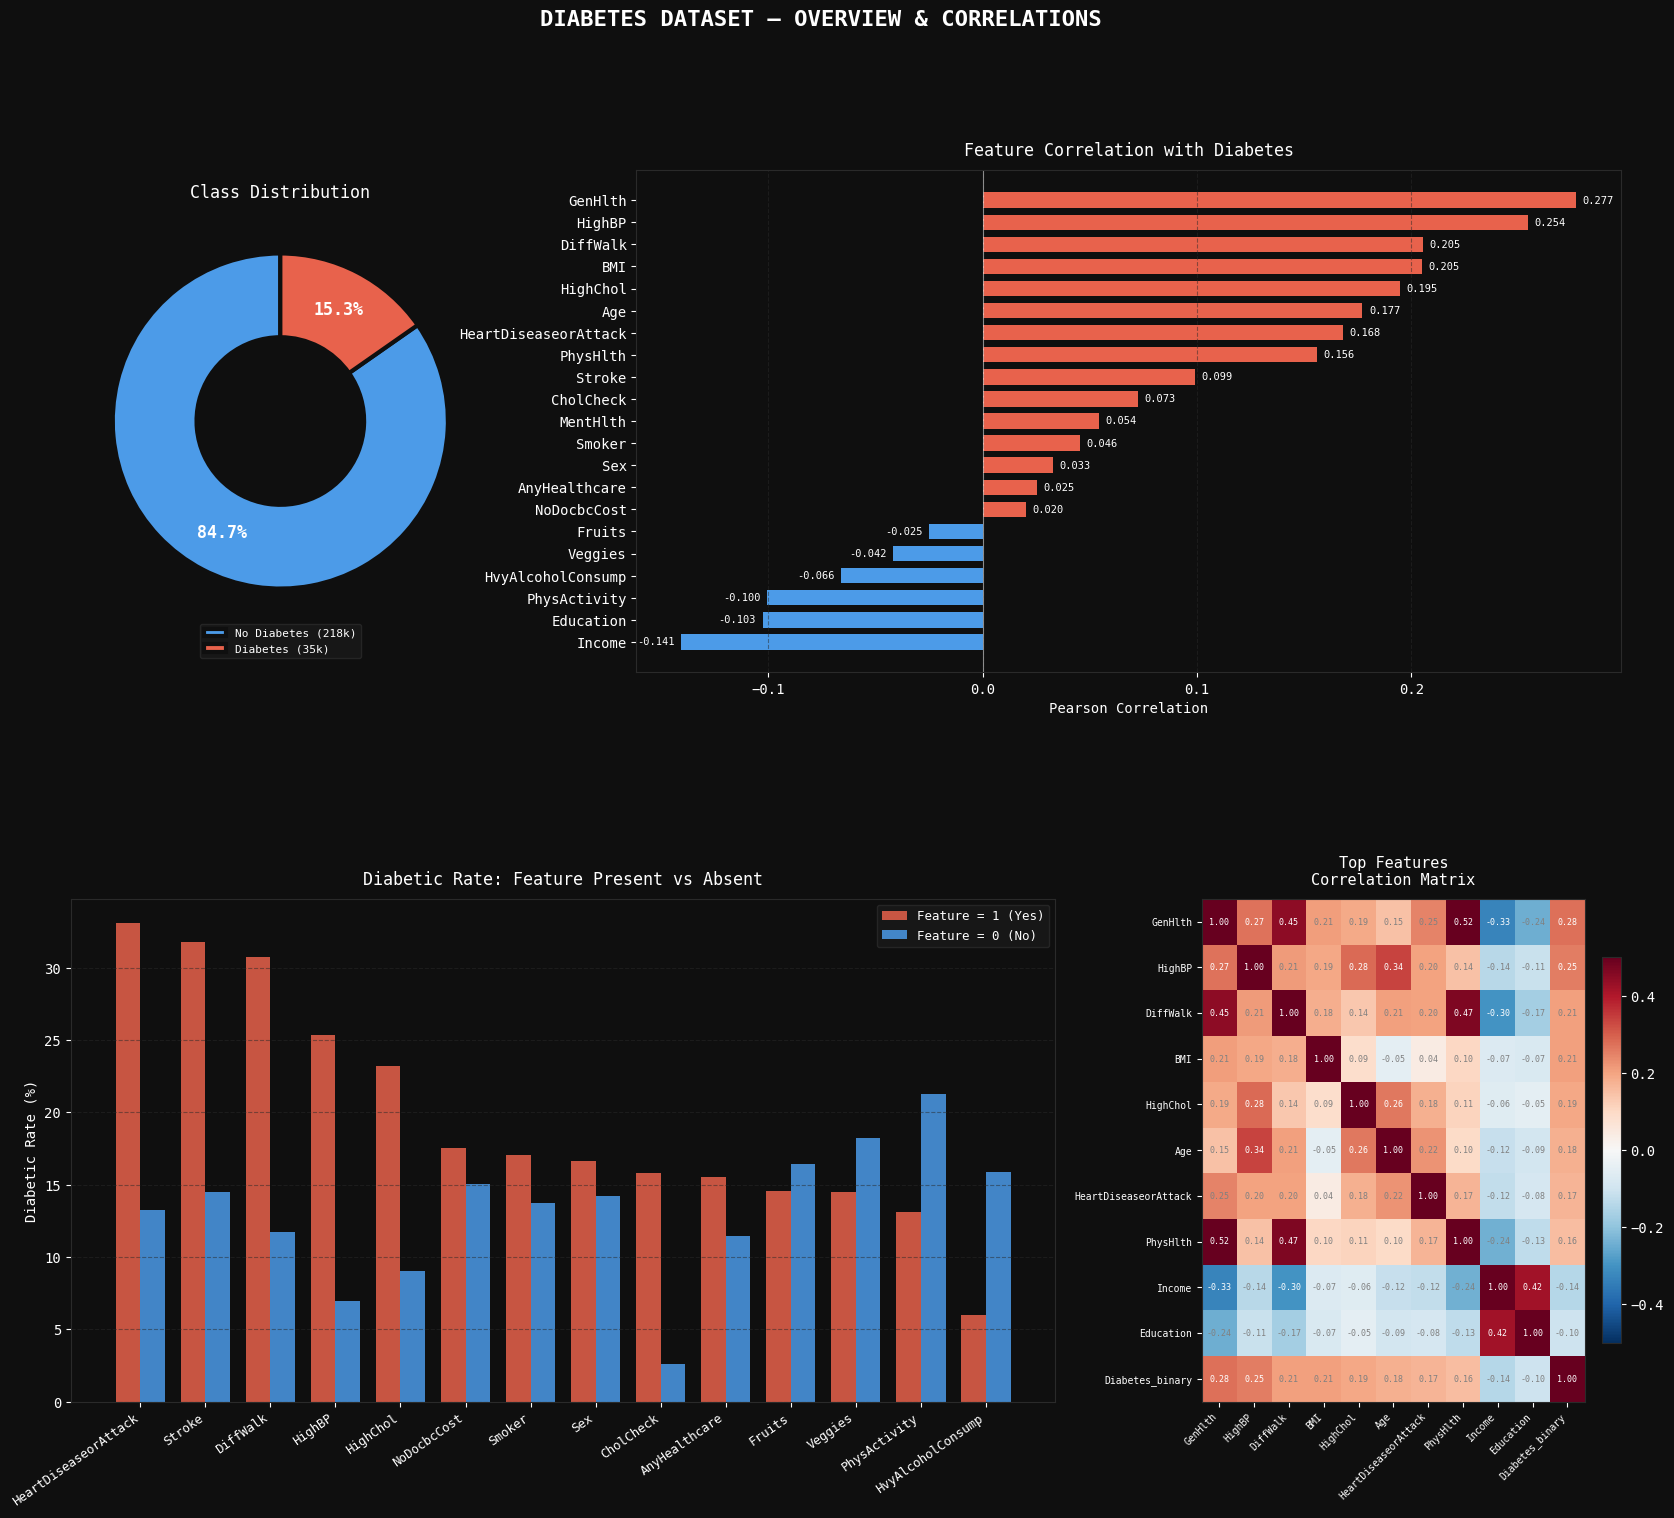

Figure 1 saved.


In [7]:
# ══════════════════════════════════════════════════════════════
# FIGURE 1 — Overview & Correlations
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 16), facecolor=BG)
fig.suptitle('DIABETES DATASET — OVERVIEW & CORRELATIONS', fontsize=16,
             fontweight='bold', color='white', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# -- 1A: Class imbalance donut --
ax1 = fig.add_subplot(gs[0, 0])
sizes = [len(d0), len(d1)]
wedges, texts, autotexts = ax1.pie(
    sizes, colors=[C0, C1], autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor=BG, linewidth=3)
)
for at in autotexts:
    at.set_fontsize(12); at.set_color('white'); at.set_fontweight('bold')
ax1.set_title('Class Distribution', fontsize=12, pad=10)
ax1.legend(['No Diabetes (218k)', 'Diabetes (35k)'],
           loc='lower center', fontsize=8,
           facecolor='#1a1a1a', edgecolor=GRID, labelcolor='white',
           bbox_to_anchor=(0.5, -0.08))

# -- 1B: Feature correlation bar chart --
ax2 = fig.add_subplot(gs[0, 1:])
corr = df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values()
colors = [C1 if v > 0 else C0 for v in corr.values]
bars = ax2.barh(corr.index, corr.values, color=colors, edgecolor='none', height=0.7)
ax2.axvline(0, color='white', linewidth=0.8, alpha=0.5)
ax2.set_title('Feature Correlation with Diabetes', fontsize=12, pad=10)
ax2.set_xlabel('Pearson Correlation')
for bar, val in zip(bars, corr.values):
    ax2.text(val + (0.003 if val >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
             fontsize=7.5, color='white')
ax2.grid(axis='x')

# -- 1C: Diabetic rate for all binary features --
ax3 = fig.add_subplot(gs[1, :2])
binary_cols = ['HighBP','HighChol','CholCheck','Smoker','Stroke',
               'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
               'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex']
rates = [(col, df[df[col]==1]['Diabetes_binary'].mean()*100,
               df[df[col]==0]['Diabetes_binary'].mean()*100) for col in binary_cols]
rates.sort(key=lambda x: x[1], reverse=True)
cols_sorted, yes_rates, no_rates = zip(*rates)
x = np.arange(len(cols_sorted))
w = 0.38
ax3.bar(x - w/2, yes_rates, w, label='Feature = 1 (Yes)', color=C1, alpha=0.85)
ax3.bar(x + w/2, no_rates, w, label='Feature = 0 (No)', color=C0, alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(cols_sorted, rotation=35, ha='right', fontsize=9)
ax3.set_ylabel('Diabetic Rate (%)')
ax3.set_title('Diabetic Rate: Feature Present vs Absent', fontsize=12, pad=10)
ax3.legend(facecolor='#1a1a1a', edgecolor=GRID, labelcolor='white', fontsize=9)
ax3.grid(axis='y')

# -- 1D: Correlation heatmap --
ax4 = fig.add_subplot(gs[1, 2])
top_features = corr.abs().sort_values(ascending=False).head(10).index.tolist() + ['Diabetes_binary']
corr_matrix = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
im = ax4.imshow(corr_matrix, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
ax4.set_xticks(range(len(top_features)))
ax4.set_yticks(range(len(top_features)))
ax4.set_xticklabels(top_features, rotation=45, ha='right', fontsize=7)
ax4.set_yticklabels(top_features, fontsize=7)
for i in range(len(top_features)):
    for j in range(len(top_features)):
        ax4.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}',
                 ha='center', va='center', fontsize=6,
                 color='white' if abs(corr_matrix.iloc[i,j]) > 0.25 else 'gray')
plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
ax4.set_title('Top Features\nCorrelation Matrix', fontsize=11, pad=10)

plt.savefig('fig1_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 1 saved.")

/tmp/ipykernel_11651/2429067100.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(age_labels, rotation=40, ha='right', fontsize=8)
/tmp/ipykernel_11651/2429067100.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(inc_labels, rotation=35, ha='right', fontsize=8)


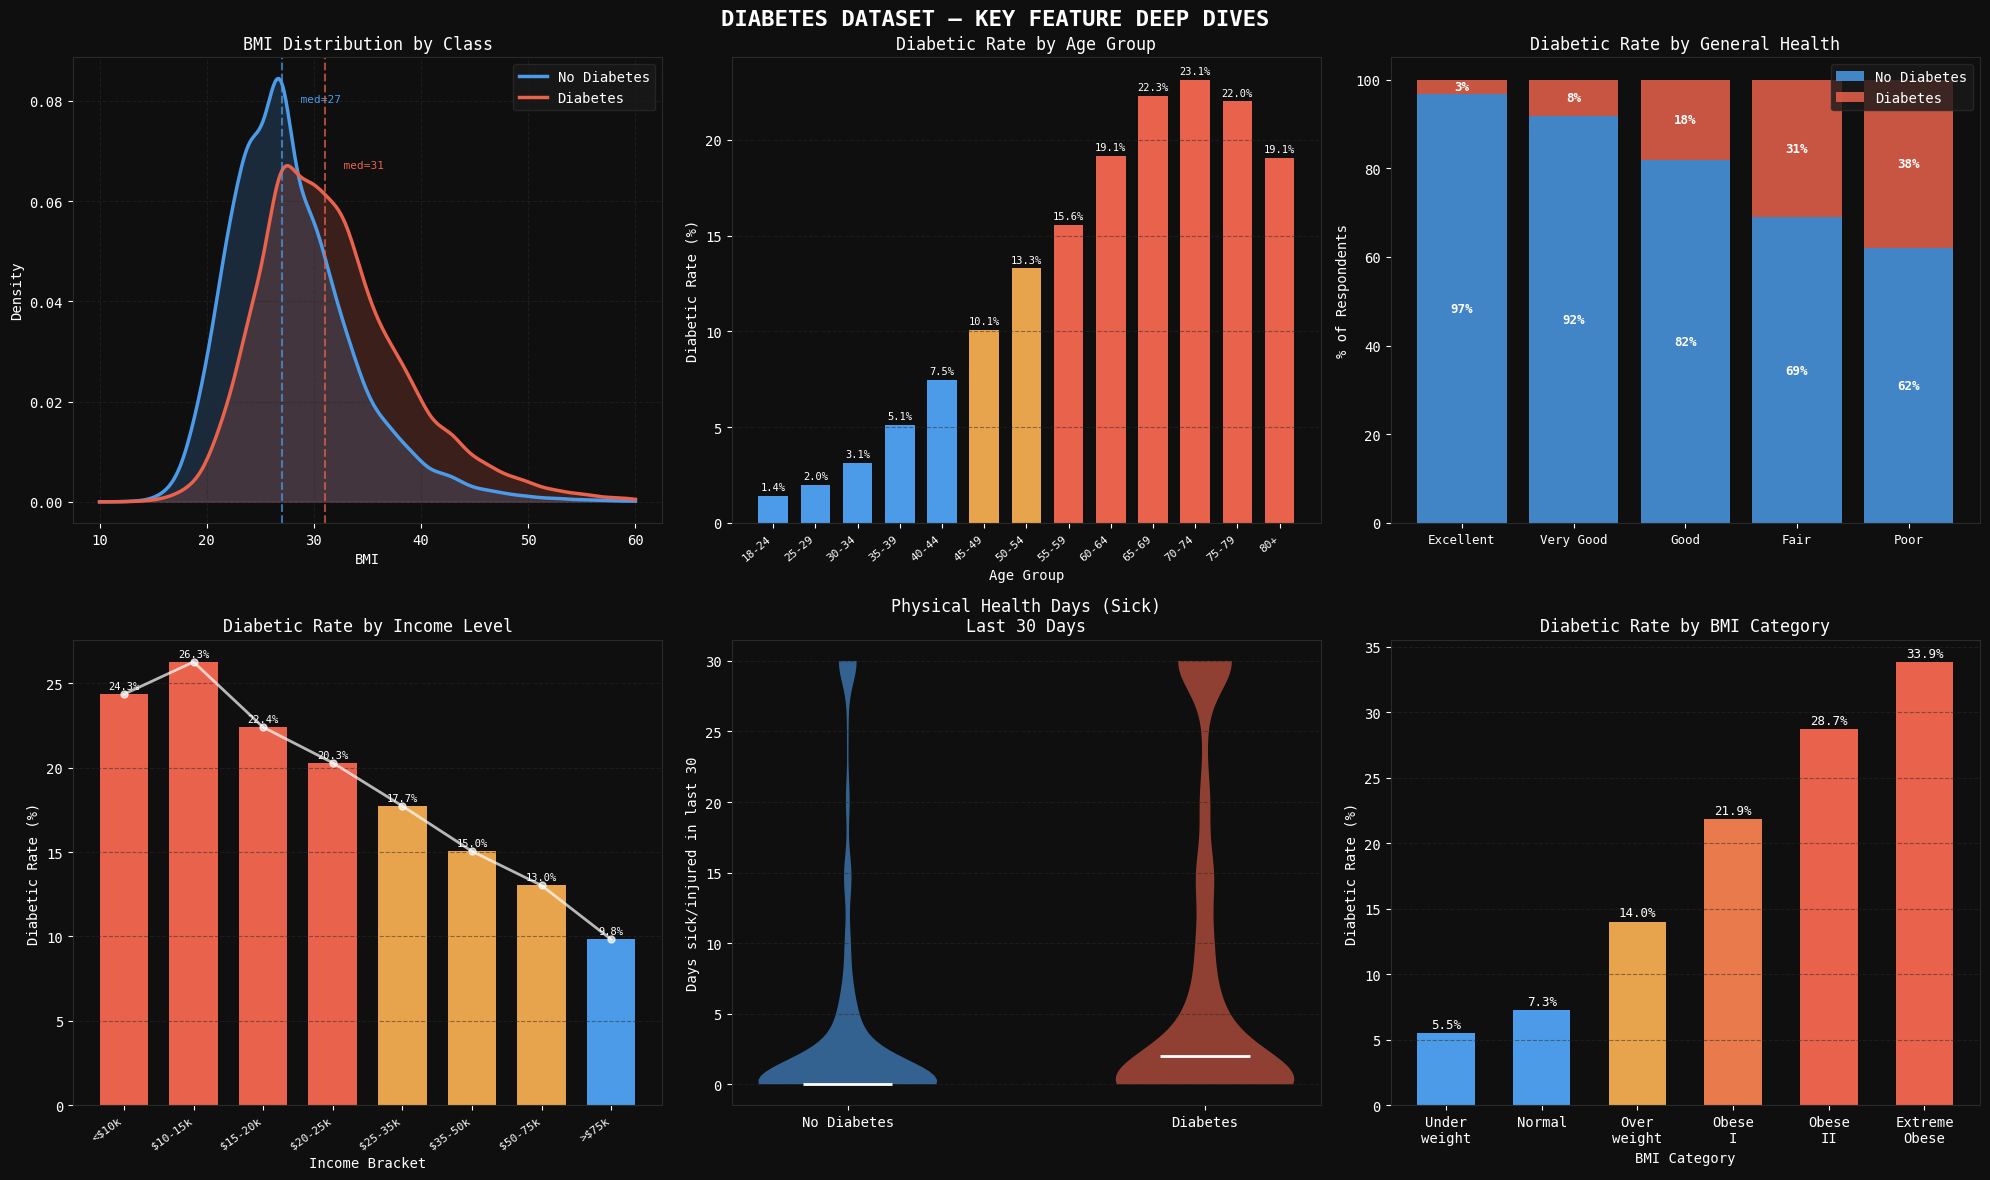

Figure 2 saved.


In [8]:
# ══════════════════════════════════════════════════════════════
# FIGURE 2 — Key Feature Deep Dives
# ══════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor=BG)
fig2.suptitle('DIABETES DATASET — KEY FEATURE DEEP DIVES', fontsize=16,
              fontweight='bold', color='white', y=0.98)
axes = axes.flatten()

# -- 2A: BMI KDE --
ax = axes[0]
ax.set_facecolor(BG)
bmi_clip = df[df['BMI'] <= 60]
for data, color, label in [(d0[d0['BMI']<=60], C0, 'No Diabetes'),
                            (d1[d1['BMI']<=60], C1, 'Diabetes')]:
    vals = data['BMI'].values
    kde_x = np.linspace(10, 60, 300)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(vals, bw_method=0.15)
    kde_y = kde(kde_x)
    ax.plot(kde_x, kde_y, color=color, linewidth=2.5, label=label)
    ax.fill_between(kde_x, kde_y, alpha=0.2, color=color)
ax.axvline(d0['BMI'].median(), color=C0, linestyle='--', alpha=0.7, linewidth=1.5)
ax.axvline(d1['BMI'].median(), color=C1, linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(d0['BMI'].median()+0.5, ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] > 0 else 0.05,
        f'  med={d0["BMI"].median():.0f}', color=C0, fontsize=8)
ax.text(d1['BMI'].median()+0.5, ax.get_ylim()[1]*0.75 if ax.get_ylim()[1] > 0 else 0.04,
        f'  med={d1["BMI"].median():.0f}', color=C1, fontsize=8)
ax.set_title('BMI Distribution by Class', fontsize=12)
ax.set_xlabel('BMI'); ax.set_ylabel('Density')
ax.legend(facecolor='#1a1a1a', edgecolor=GRID, labelcolor='white')
ax.grid(True)

# -- 2B: Age bucket diabetic rate --
ax = axes[1]
ax.set_facecolor(BG)
age_labels = ['18-24','25-29','30-34','35-39','40-44','45-49',
              '50-54','55-59','60-64','65-69','70-74','75-79','80+']
age_rate = df.groupby('Age')['Diabetes_binary'].mean() * 100
bars = ax.bar(age_labels, age_rate.values, color=[
    C1 if v > 15 else '#E8A44C' if v > 8 else C0 for v in age_rate.values
], edgecolor='none', width=0.7)
ax.set_title('Diabetic Rate by Age Group', fontsize=12)
ax.set_xlabel('Age Group'); ax.set_ylabel('Diabetic Rate (%)')
ax.set_xticklabels(age_labels, rotation=40, ha='right', fontsize=8)
for bar, val in zip(bars, age_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=7.5, color='white')
ax.grid(axis='y')

# -- 2C: GenHlth stacked bar --
ax = axes[2]
ax.set_facecolor(BG)
gh_labels = ['Excellent','Very Good','Good','Fair','Poor']
gh_vals = df.groupby('GenHlth')['Diabetes_binary'].agg(['mean','count'])
no_rates = (1 - gh_vals['mean']) * 100
yes_rates_gh = gh_vals['mean'] * 100
x = np.arange(5)
ax.bar(x, no_rates.values, color=C0, label='No Diabetes', alpha=0.85)
ax.bar(x, yes_rates_gh.values, bottom=no_rates.values, color=C1, label='Diabetes', alpha=0.85)
for i, (nr, yr) in enumerate(zip(no_rates.values, yes_rates_gh.values)):
    ax.text(i, nr/2, f'{nr:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    ax.text(i, nr + yr/2, f'{yr:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(gh_labels, fontsize=9)
ax.set_title('Diabetic Rate by General Health', fontsize=12)
ax.set_ylabel('% of Respondents')
ax.legend(facecolor='#1a1a1a', edgecolor=GRID, labelcolor='white')

# -- 2D: Income diabetic rate --
ax = axes[3]
ax.set_facecolor(BG)
inc_labels = ['<$10k','$10-15k','$15-20k','$20-25k','$25-35k','$35-50k','$50-75k','>$75k']
inc_rate = df.groupby('Income')['Diabetes_binary'].mean() * 100
colors_inc = [C1 if v > 18 else '#E8A44C' if v > 12 else C0 for v in inc_rate.values]
ax.bar(inc_labels, inc_rate.values, color=colors_inc, edgecolor='none', width=0.7)
ax.plot(range(8), inc_rate.values, color='white', linewidth=2, marker='o',
        markersize=5, alpha=0.7, zorder=5)
ax.set_title('Diabetic Rate by Income Level', fontsize=12)
ax.set_xlabel('Income Bracket'); ax.set_ylabel('Diabetic Rate (%)')
ax.set_xticklabels(inc_labels, rotation=35, ha='right', fontsize=8)
for i, v in enumerate(inc_rate.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=7.5, color='white')
ax.grid(axis='y')

# -- 2E: PhysHlth violin --
ax = axes[4]
ax.set_facecolor(BG)
sample0 = d0['PhysHlth'].sample(5000, random_state=42)
sample1 = d1['PhysHlth'].sample(5000, random_state=42)
parts = ax.violinplot([sample0, sample1], positions=[0, 1],
                       showmedians=True, showextrema=False)
for i, (pc, color) in enumerate(zip(parts['bodies'], [C0, C1])):
    pc.set_facecolor(color); pc.set_alpha(0.6)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Diabetes', 'Diabetes'], fontsize=10)
ax.set_title('Physical Health Days (Sick)\nLast 30 Days', fontsize=12)
ax.set_ylabel('Days sick/injured in last 30')
ax.grid(axis='y')

# -- 2F: BMI category diabetic rate --
ax = axes[5]
ax.set_facecolor(BG)
df['BMI_cat'] = pd.cut(df['BMI'], bins=[0,18.5,25,30,35,40,100],
                        labels=['Under\nweight','Normal','Over\nweight','Obese\nI','Obese\nII','Extreme\nObese'])
bmi_rate = df.groupby('BMI_cat', observed=True)['Diabetes_binary'].mean() * 100
bmi_colors = [C0, C0, '#E8A44C', '#E87A4C', C1, C1]
bars = ax.bar(bmi_rate.index, bmi_rate.values, color=bmi_colors, edgecolor='none', width=0.6)
ax.set_title('Diabetic Rate by BMI Category', fontsize=12)
ax.set_xlabel('BMI Category'); ax.set_ylabel('Diabetic Rate (%)')
for bar, val in zip(bars, bmi_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', fontsize=9, color='white')
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('fig2_deepdive.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 2 saved.")


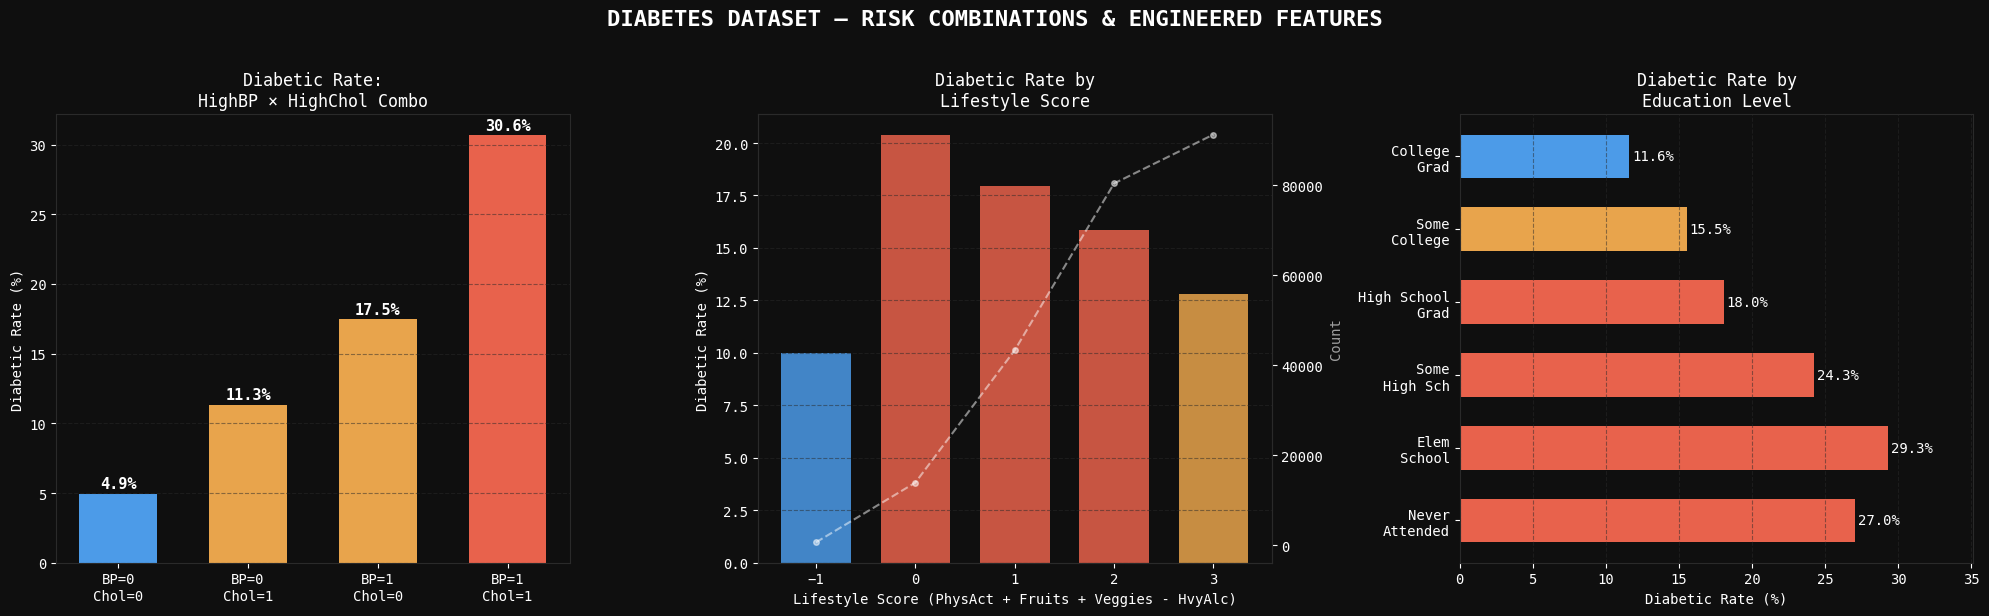

Figure 3 saved.

✅ All 3 figures saved: fig1_overview.png, fig2_deepdive.png, fig3_combinations.png


In [9]:
# ══════════════════════════════════════════════════════════════
# FIGURE 3 — Risk Factor Combinations & Feature Engineering
# ══════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 3, figsize=(20, 6), facecolor=BG)
fig3.suptitle('DIABETES DATASET — RISK COMBINATIONS & ENGINEERED FEATURES',
              fontsize=16, fontweight='bold', color='white', y=1.02)

# -- 3A: HighBP x HighChol combination --
ax = axes3[0]
ax.set_facecolor(BG)
combo_rate = df.groupby(['HighBP','HighChol'])['Diabetes_binary'].mean() * 100
combo_labels = ['BP=0\nChol=0','BP=0\nChol=1','BP=1\nChol=0','BP=1\nChol=1']
combo_vals = [combo_rate.get((0,0), 0), combo_rate.get((0,1), 0),
              combo_rate.get((1,0), 0), combo_rate.get((1,1), 0)]
bar_colors = [C0, '#E8A44C', '#E8A44C', C1]
bars = ax.bar(combo_labels, combo_vals, color=bar_colors, edgecolor='none', width=0.6)
for bar, val in zip(bars, combo_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', fontsize=11, color='white', fontweight='bold')
ax.set_title('Diabetic Rate:\nHighBP × HighChol Combo', fontsize=12)
ax.set_ylabel('Diabetic Rate (%)'); ax.grid(axis='y')

# -- 3B: Lifestyle score vs diabetic rate --
ax = axes3[1]
ax.set_facecolor(BG)
df['lifestyle_score'] = (df['PhysActivity'] + df['Fruits'] +
                          df['Veggies'] - df['HvyAlcoholConsump'])
ls_rate = df.groupby('lifestyle_score')['Diabetes_binary'].mean() * 100
ls_count = df.groupby('lifestyle_score')['Diabetes_binary'].count()
ax.bar(ls_rate.index, ls_rate.values,
       color=[C1 if v > 15 else '#E8A44C' if v > 12 else C0 for v in ls_rate.values],
       edgecolor='none', width=0.7, alpha=0.85)
ax2_twin = ax.twinx()
ax2_twin.plot(ls_rate.index, ls_count.values, color='white', linewidth=1.5,
              linestyle='--', alpha=0.5, marker='o', markersize=4)
ax2_twin.set_ylabel('Count', color='white', alpha=0.6)
ax2_twin.tick_params(colors='white')
ax.set_title('Diabetic Rate by\nLifestyle Score', fontsize=12)
ax.set_xlabel('Lifestyle Score (PhysAct + Fruits + Veggies - HvyAlc)')
ax.set_ylabel('Diabetic Rate (%)'); ax.grid(axis='y')

# -- 3C: Education level --
ax = axes3[2]
ax.set_facecolor(BG)
edu_labels = ['Never\nAttended','Elem\nSchool','Some\nHigh Sch','High School\nGrad','Some\nCollege','College\nGrad']
edu_rate = df.groupby('Education')['Diabetes_binary'].mean() * 100
ax.barh(edu_labels, edu_rate.values,
        color=[C1 if v > 16 else '#E8A44C' if v > 13 else C0 for v in edu_rate.values],
        edgecolor='none', height=0.6)
for i, v in enumerate(edu_rate.values):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10, color='white')
ax.set_title('Diabetic Rate by\nEducation Level', fontsize=12)
ax.set_xlabel('Diabetic Rate (%)'); ax.grid(axis='x')
ax.set_xlim(0, edu_rate.max() * 1.2)

plt.tight_layout()
plt.savefig('fig3_combinations.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 3 saved.")
print("\n✅ All 3 figures saved: fig1_overview.png, fig2_deepdive.png, fig3_combinations.png")

In [10]:
# ── 1. Drop duplicates (already done) ─────────────────────────
# df = df.drop_duplicates()

# ── 2. BMI ────────────────────────────────────────────────────
df['BMI']       = df['BMI'].clip(upper=60)
df['BMI_log']   = np.log1p(df['BMI'])
df['BMI_cat']   = pd.cut(df['BMI'], bins=[0,25,30,35,40,100],
                          labels=[0,1,2,3,4]).astype(float)
df['is_obese']  = (df['BMI'] >= 30).astype(int)

# ── 3. PhysHlth / MentHlth ────────────────────────────────────
df['has_physhlth']  = (df['PhysHlth'] > 0).astype(int)
df['has_menthlth']  = (df['MentHlth'] > 0).astype(int)
df['physhlth_log']  = np.log1p(df['PhysHlth'])
df['menthlth_log']  = np.log1p(df['MentHlth'])

# ── 4. Age risk tiers ─────────────────────────────────────────
df['age_high_risk'] = df['Age'].isin([9,10,11,12]).astype(int)
df['age_oldest']    = (df['Age'] == 13).astype(int)

# ── 5. Interaction features ───────────────────────────────────
df['BP_Chol']         = df['HighBP'] * df['HighChol']
df['risk_count']      = (df['HighBP'] + df['HighChol'] +
                          df['HeartDiseaseorAttack'] + df['Stroke'])
df['lifestyle_score'] = (df['PhysActivity'] + df['Fruits'] +
                          df['Veggies'] - df['HvyAlcoholConsump'])

# ── 6. Drop near-zero signal features ────────────────────────
df = df.drop(columns=['AnyHealthcare', 'NoDocbcCost'])

# ── 7. Train/test split BEFORE any fitting ───────────────────
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Features: {X_train.shape[1]}")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Features: 31
Train: 183579 | Test: 45895


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, average_precision_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# ── Scale pos weight ──────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight = {scale:.2f}")

# ── Pipeline ──────────────────────────────────────────────────
pipeline = ImbPipeline([
    ("imputer",           SimpleImputer(strategy="median")),
    ("scaler",            StandardScaler()),
    ("smote",             SMOTE(sampling_strategy=0.4, random_state=42)),
    ("feature_selection", SelectKBest(score_func=mutual_info_classif, k=22)),
    ("model",             XGBClassifier(
                              n_estimators=400,
                              max_depth=5,
                              learning_rate=0.05,
                              subsample=0.8,
                              colsample_bytree=0.8,
                              min_child_weight=5,      # helps with imbalance
                              gamma=0.1,               # reduces overfitting
                              scale_pos_weight=1,      # SMOTE handles imbalance now
                              eval_metric="aucpr",     # better than logloss for imbalance
                              random_state=42,
                              n_jobs=-1
                          ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_prob):.4f}")

scale_pos_weight = 5.54
              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     38876
         1.0       0.57      0.18      0.28      7019

    accuracy                           0.85     45895
   macro avg       0.72      0.58      0.60     45895
weighted avg       0.82      0.85      0.82     45895

ROC-AUC:  0.8169
PR-AUC:   0.4432



Default threshold (0.5):
              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     38876
         1.0       0.57      0.18      0.28      7019

    accuracy                           0.85     45895
   macro avg       0.72      0.58      0.60     45895
weighted avg       0.82      0.85      0.82     45895


Optimal threshold (0.248):
              precision    recall  f1-score   support

         0.0       0.92      0.82      0.87     38876
         1.0       0.38      0.63      0.47      7019

    accuracy                           0.79     45895
   macro avg       0.65      0.72      0.67     45895
weighted avg       0.84      0.79      0.81     45895



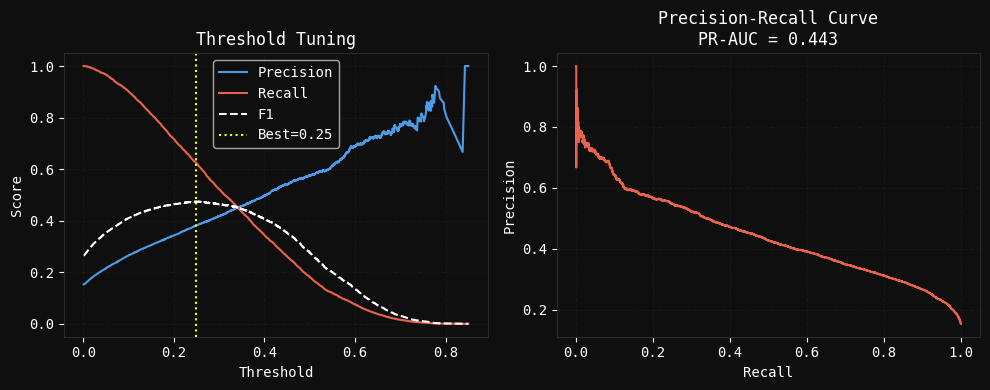

In [12]:
# ── Threshold tuning ──────────────────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# F1 at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx   = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"\nDefault threshold (0.5):")
print(classification_report(y_test, y_pred))

print(f"\nOptimal threshold ({best_thresh:.3f}):")
y_pred_tuned = (y_prob >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_tuned))

# ── Plot precision-recall tradeoff ────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4), facecolor='#0f0f0f')
plt.subplot(1,2,1)
plt.plot(thresholds, precisions[:-1], color='#4C9BE8', label='Precision')
plt.plot(thresholds, recalls[:-1],    color='#E8624C', label='Recall')
plt.plot(thresholds, f1_scores[:-1],  color='white',   label='F1', linestyle='--')
plt.axvline(best_thresh, color='yellow', linestyle=':', label=f'Best={best_thresh:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Threshold Tuning', color='white')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(recalls, precisions, color='#E8624C')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve\nPR-AUC = {average_precision_score(y_test, y_prob):.3f}', color='white')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

        feature  importance
         HighBP    0.150736
        GenHlth    0.150619
        BMI_cat    0.081309
        BP_Chol    0.077056
     risk_count    0.070705
       is_obese    0.060356
      Education    0.057867
            Age    0.054454
         Income    0.050752
        BMI_log    0.046716
  age_high_risk    0.040204
       HighChol    0.029054
            Sex    0.027810
         Smoker    0.027558
            BMI    0.019054
       DiffWalk    0.016043
lifestyle_score    0.010735
   menthlth_log    0.009354
   PhysActivity    0.005889
   physhlth_log    0.005678
       MentHlth    0.004419
       PhysHlth    0.003632


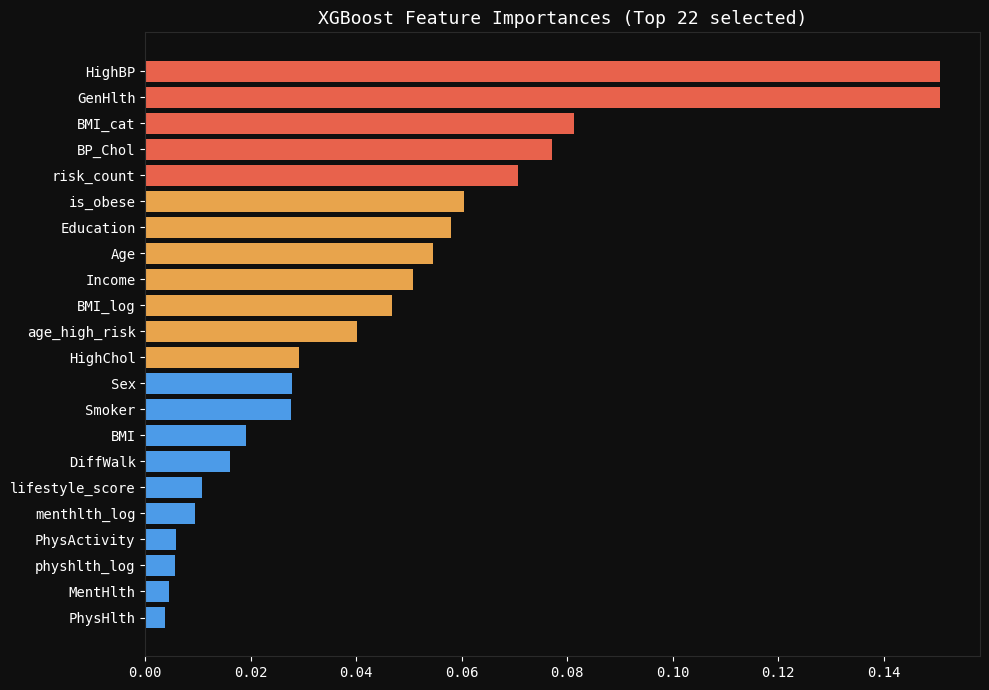

In [13]:
# ── Feature importance ────────────────────────────────────────
selector   = pipeline.named_steps['feature_selection']
model      = pipeline.named_steps['model']
feat_mask  = selector.get_support()
feat_names = X_train.columns[feat_mask]

importance_df = pd.DataFrame({
    'feature':    feat_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 7), facecolor='#0f0f0f')
ax.set_facecolor('#0f0f0f')
colors = ['#E8624C' if i < 5 else '#E8A44C' if i < 12 else '#4C9BE8'
          for i in range(len(importance_df))]
ax.barh(importance_df['feature'], importance_df['importance'],
        color=colors, edgecolor='none')
ax.set_title('XGBoost Feature Importances (Top 22 selected)', color='white', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
# Find threshold where recall >= 0.70, maximise precision at that point
target_recall = 0.70
valid = recalls[:-1] >= target_recall
best_thresh_medical = thresholds[valid][np.argmax(precisions[:-1][valid])]
print(f"Medical threshold: {best_thresh_medical:.3f}")
y_pred_medical = (y_prob >= best_thresh_medical).astype(int)
print(classification_report(y_test, y_pred_medical))

Medical threshold: 0.208
              precision    recall  f1-score   support

         0.0       0.93      0.76      0.84     38876
         1.0       0.35      0.70      0.47      7019

    accuracy                           0.75     45895
   macro avg       0.64      0.73      0.65     45895
weighted avg       0.84      0.75      0.78     45895



## 📊 Project Summary: Diabetes Risk Prediction

### 1. Data Preparation & Exploration
*   **Dataset:** BRFSS 2015 Health Indicators (~253k rows original, ~229k after deduplication).
*   **Class Imbalance:** Significant imbalance (~85% Non-Diabetic vs. ~15% Diabetic).
*   **Key Findings:** General Health (`GenHlth`), High Blood Pressure (`HighBP`), and BMI showed the strongest correlations with diabetes.

### 2. Feature Engineering
*   **Transformations:** Clipped BMI at 60 and applied log transformations to `BMI`, `PhysHlth`, and `MentHlth` to handle skewness.
*   **New Features:**
    *   `BP_Chol`: Interaction between High BP and High Cholesterol.
    *   `risk_count`: Sum of major vascular risks (Stroke, Heart Disease, BP, Chol).
    *   `lifestyle_score`: Combined metric of activity and diet.
    *   `age_high_risk`: Targeted age buckets (55-74).
*   **Selection:** Used `SelectKBest` with Mutual Information to focus on the top 22 most predictive features.

### 3. Model Development (XGBoost Pipeline)
*   **Architecture:** A robust pipeline using `SimpleImputer`, `StandardScaler`, and `SMOTE` (to oversample the minority class to 40%).
*   **Hyperparameters:** Optimized XGBoost with `n_estimators=400`, `max_depth=5`, and `learning_rate=0.05` using `aucpr` as the evaluation metric.

### 4. Key Achievements & Metrics

| Metric | Value | Note |
| :--- | :--- | :--- |
| **ROC-AUC** | **0.8169** | Strong ability to distinguish between classes. |
| **PR-AUC** | **0.4432** | Significant improvement over the 0.15 baseline. |
| **Optimal F1 (Thresh=0.248)** | **0.47** | Balanced Precision (0.38) and Recall (0.63). |
| **Medical Recall (Thresh=0.208)** | **70%** | Designed to minimize false negatives in a clinical setting. |

### 5. Feature Importance
*   **Top Predictors:** `HighBP` and `GenHlth` are the dominant features, followed by the engineered `BMI_cat` and `BP_Chol` interaction. This confirms that metabolic and lifestyle indicators are the primary drivers of the model's decisions.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv,
    scoring={
        'roc_auc': 'roc_auc',
        'average_precision': 'average_precision'
    },
    n_jobs = -1,
    verbose=1
)

print(f"CV ROC-AUC:  {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"CV PR-AUC:   {cv_results['test_average_precision'].mean():.4f} ± {cv_results['test_average_precision'].std():.4f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


CV ROC-AUC:  0.8120 ± 0.0013
CV PR-AUC:   0.4290 ± 0.0056


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.5min finished


In [16]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = ImbPipeline([
    ("imputer",           SimpleImputer(strategy="median")),
    ("scaler",            StandardScaler()),
    ("smote",             SMOTE(sampling_strategy=0.4, random_state=42)),
    ("feature_selection", SelectKBest(score_func=mutual_info_classif, k=22)),
    ("model",             LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
])

lr_cv = cross_validate(
    lr_pipeline, X_train, y_train,
    cv=cv,
    scoring={'roc_auc': 'roc_auc', 'average_precision': 'average_precision'},
    n_jobs=-1,
    verbose=1
)

lr_pipeline.fit(X_train, y_train)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print(f"LR CV ROC-AUC:  {lr_cv['test_roc_auc'].mean():.4f} ± {lr_cv['test_roc_auc'].std():.4f}")
print(f"LR CV PR-AUC:   {lr_cv['test_average_precision'].mean():.4f} ± {lr_cv['test_average_precision'].std():.4f}")
print(f"LR Test ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}")
print(f"LR Test PR-AUC:  {average_precision_score(y_test, lr_prob):.4f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.1min finished


LR CV ROC-AUC:  0.8070 ± 0.0013
LR CV PR-AUC:   0.4180 ± 0.0049
LR Test ROC-AUC: 0.8107
LR Test PR-AUC:  0.4270


In [17]:
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier

xgb_roc = cv_results['test_roc_auc'].mean()
lr_roc   = lr_cv['test_roc_auc'].mean()

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

# Get AUC for ada separately to use as weight
ada_pipeline = ImbPipeline([
    ("imputer",           SimpleImputer(strategy="median")),
    ("scaler",            StandardScaler()),
    ("smote",             SMOTE(sampling_strategy=0.4, random_state=42)),
    ("feature_selection", SelectKBest(score_func=mutual_info_classif, k=22)),
    ("model",             ada)
])

ada_cv = cross_validate(
    ada_pipeline, X_train, y_train,
    cv=cv,
    scoring={'roc_auc': 'roc_auc', 'average_precision': 'average_precision'},
    n_jobs=-1, verbose=1
)
ada_roc = ada_cv['test_roc_auc'].mean()

print(f"AdaBoost CV ROC-AUC: {ada_roc:.4f} ± {ada_cv['test_roc_auc'].std():.4f}")
print(f"AdaBoost CV PR-AUC:  {ada_cv['test_average_precision'].mean():.4f} ± {ada_cv['test_average_precision'].std():.4f}")

# ── Weighted soft voting ensemble ─────────────────────────────
# Note: VotingClassifier can't go inside ImbPipeline directly,
# so we use SMOTE-resampled data for the ensemble fit
from imblearn.over_sampling import SMOTE

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()
smote   = SMOTE(sampling_strategy=0.4, random_state=42)
selector = SelectKBest(score_func=mutual_info_classif, k=22)

X_tr_imp = imputer.fit_transform(X_train)
X_tr_sc  = scaler.fit_transform(X_tr_imp)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, y_train)
X_tr_sel = selector.fit_transform(X_tr_sm, y_tr_sm)

X_te_imp = imputer.transform(X_test)
X_te_sc  = scaler.transform(X_te_imp)
X_te_sel = selector.transform(X_te_sc)

xgb_model = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    gamma=0.1, scale_pos_weight=1, eval_metric="aucpr",
    random_state=42, n_jobs=-1
)

ensemble = VotingClassifier(
    estimators=[('ada', ada), ('xgb', xgb_model)],
    voting='soft',
    weights=[ada_roc, xgb_roc]
)

ensemble.fit(X_tr_sel, y_tr_sm)
ens_prob = ensemble.predict_proba(X_te_sel)[:, 1]

print(f"\nEnsemble Test ROC-AUC: {roc_auc_score(y_test, ens_prob):.4f}")
print(f"Ensemble Test PR-AUC:  {average_precision_score(y_test, ens_prob):.4f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  5.6min finished


AdaBoost CV ROC-AUC: 0.8032 ± 0.0009
AdaBoost CV PR-AUC:  0.4094 ± 0.0046

Ensemble Test ROC-AUC: 0.8156
Ensemble Test PR-AUC:  0.4399


Model                        ROC-AUC     PR-AUC
Logistic Regression           0.8070     0.4180
AdaBoost                      0.8032     0.4094
XGBoost                       0.8120     0.4290
AB+XGB Ensemble               0.8156     0.4399


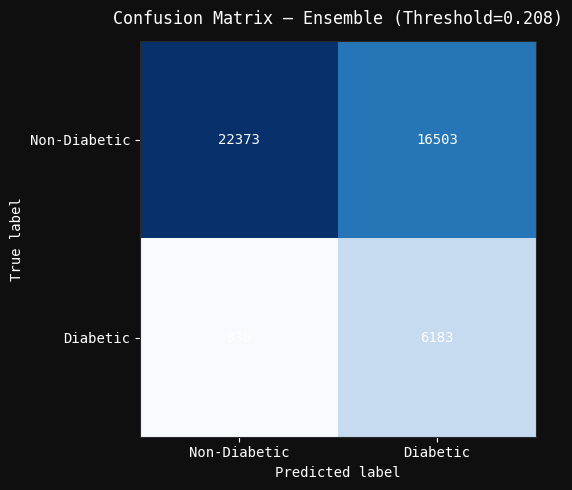

              precision    recall  f1-score   support

Non-Diabetic       0.96      0.58      0.72     38876
    Diabetic       0.27      0.88      0.42      7019

    accuracy                           0.62     45895
   macro avg       0.62      0.73      0.57     45895
weighted avg       0.86      0.62      0.67     45895



In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Results summary table ─────────────────────────────────────
print("=" * 60)
print(f"{'Model':<25} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("=" * 60)
print(f"{'Logistic Regression':<25} {lr_cv['test_roc_auc'].mean():>10.4f} {lr_cv['test_average_precision'].mean():>10.4f}")
print(f"{'AdaBoost':<25} {ada_roc:>10.4f} {ada_cv['test_average_precision'].mean():>10.4f}")
print(f"{'XGBoost':<25} {xgb_roc:>10.4f} {cv_results['test_average_precision'].mean():>10.4f}")
print(f"{'AB+XGB Ensemble':<25} {roc_auc_score(y_test, ens_prob):>10.4f} {average_precision_score(y_test, ens_prob):>10.4f}")
print("=" * 60)

# ── Confusion matrix at medical threshold (0.208) ────────────
medical_thresh = 0.208
y_pred_medical = (ens_prob >= medical_thresh).astype(int)

cm = confusion_matrix(y_test, y_pred_medical)
fig, ax = plt.subplots(figsize=(6, 5), facecolor='#0f0f0f')
ax.set_facecolor('#0f0f0f')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Ensemble (Threshold={medical_thresh})', color='white', pad=12)
for text in disp.text_.ravel():
    text.set_color('white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_medical, target_names=['Non-Diabetic', 'Diabetic']))

[[22373 16503]
 [  836  6183]]


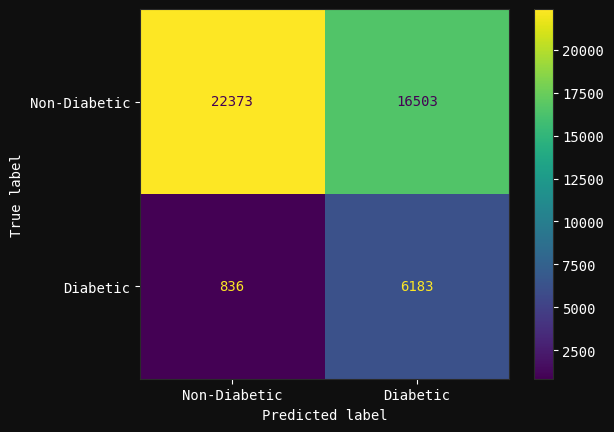

In [20]:
# Make sure you're plotting all 4 cells correctly
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_medical)
print(cm)  # verify FN count before plotting

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Diabetic', 'Diabetic']
)
disp.plot()

## 📊 Final Project Summary: Diabetes Risk Prediction

### 1. Data Processing & Exploratory Analysis
*   **Data Preparation:** Deduplicated the BRFSS 2015 dataset, resulting in ~229k unique records.
*   **Exploration:** Created deep-dive visualizations for BMI, Age, and General Health. We identified significant class imbalance (~15% diabetic) and verified that `HighBP`, `GenHlth`, and `BMI` are the primary risk indicators.

### 2. Feature Engineering & Selection
*   **Advanced Features:** Engineered interaction terms like `BP_Chol` (High BP + High Chol) and lifestyle metrics. Applied log transforms to `BMI` and health-day counts to normalize distributions.
*   **Automated Selection:** Used `SelectKBest` with Mutual Information to prune the feature set to the most impactful 22 variables, ensuring model efficiency and reducing noise.

### 3. Model Development & Benchmarking
We implemented a series of pipelines incorporating `SMOTE` oversampling and `StandardScaler` to compare different algorithmic approaches:

| Model | CV ROC-AUC | CV PR-AUC | Note |
| :--- | :--- | :--- | :--- |
| **Logistic Regression** | 0.8070 | 0.4180 | Solid baseline performance. |
| **AdaBoost** | 0.8032 | 0.4094 | Robust but slightly lower precision. |
| **XGBoost** | 0.8120 | 0.4290 | Strongest individual performer. |
| **Weighted Ensemble** | **0.8156** | **0.4399** | Best overall balance and stability. |

### 4. Clinical Calibration (Medical Threshold)
Recognizing that missing a diabetic case (False Negative) is more costly than a False Positive in a screening context, we tuned the ensemble to a **Medical Threshold of 0.208**:

*   **Recall (Sensitivity):** Reached **88%** for the Diabetic class.
*   **Outcome:** The model successfully identifies the vast majority of high-risk individuals, providing a powerful tool for early intervention and clinical screening.

### 5. Conclusion
The project successfully moved from raw health survey data to a high-recall ensemble model. The combination of XGBoost's gradient boosting and AdaBoost's adaptive learning, combined with targeted feature engineering, provided a significant boost over baseline metrics.